In [1]:
import pandas as pd
import numpy as np

In [7]:
fact = pd.read_csv('../data/fact_transactions.csv')
time = pd.read_csv('../data/dim_time.csv')
block = pd.read_csv('../data/dim_block.csv')
address = pd.read_csv('../data/dim_address.csv')

In [8]:
fact.head()

,txid,block_id,time_id,num_inputs,num_outputs,total_input,total_output,fee,vsize,weight,...,largest_output,smallest_output,input_std,output_std,input_output_ratio,fee_to_input_ratio,output_dominance,tx_density,log_total_input,log_fee
0,000000013a66f0d12cb6d75bdf6679c83b907013c0326c...,942489,40432,2,2,660,330,330,192.25,769,...,330,0,0.0,165.000000,2.000000,0.500000,1.000000,4,6.493754,5.802118
1,00000001a4cc1efcb0c15b1bf63355633bcca5af8a501f...,942488,44583,2,2,660,330,330,192.50,770,...,330,0,0.0,165.000000,2.000000,0.500000,1.000000,4,6.493754,5.802118
2,00000001bb3d4573c67c34868f2cfd0ec37ba6187b4bd3...,942490,34737,2,2,660,330,330,192.50,770,...,330,0,0.0,165.000000,2.000000,0.500000,1.000000,4,6.493754,5.802118
3,00000001e7aa893bbb8ebd88a20163717a375a126eb3c3...,942489,40432,1,3,625934,625778,156,155.25,621,...,625448,0,0.0,294761.263761,1.000249,0.000249,0.999473,4,13.347002,5.056246
4,00000001f2207da59a1e0ecb11df10306967de3599af1d...,942488,44583,1,3,2722,2566,156,155.25,621,...,2236,0,0.0,985.530427,1.060795,0.057311,0.871395,4,7.909489,5.056246


In [9]:
time.head()

,time_id,full_timestamp,hour,day,month,year,day_of_week
0,1,2026-03-27 17:28:17,17,27,3,2026,4
1,4913,2026-03-27 17:21:28,17,27,3,2026,4
2,8983,2026-03-27 17:16:59,17,27,3,2026,4
3,14369,2026-03-27 17:15:29,17,27,3,2026,4
4,19652,2026-03-27 17:09:55,17,27,3,2026,4


In [10]:
block.head()

,block_id,block_time
0,942488,2026-03-27 16:43:57
1,942489,2026-03-27 16:52:15
2,942490,2026-03-27 16:54:22
3,942491,2026-03-27 17:01:03
4,942492,2026-03-27 17:06:51


In [11]:
address.head()

,address_id,address
0,1,bc1q9ershe08ynt0zpgaajd4qvl0r2esvsh24w29hf
1,2,bc1qtzfdck2htl3qv8kce54hl32y6r59jw85ay5k89
2,3,bc1qstu9u2tyju6a7lf5hj4s2a8rrf6rtwls3702d3
3,4,bc1qyraxuru898a60p662cvqeg9kdkfvq5pp7swww5
4,8,327w9NZDp9t9BnTpZERngCjsdMZA6LDhu2


In [12]:
fact.describe()

,block_id,time_id,num_inputs,num_outputs,total_input,total_output,fee,vsize,weight,fee_rate,largest_output,smallest_output,input_std,output_std,input_output_ratio,fee_to_input_ratio,output_dominance,tx_density,log_total_input,log_fee
count,48590.000000,48590.000000,48590.000000,48590.000000,4.859000e+04,4.859000e+04,48590.000000,48590.000000,48590.000000,48590.000000,4.859000e+04,4.859000e+04,4.859000e+04,4.859000e+04,48590.000000,48590.000000,48590.000000,48590.000000,48590.000000,48590.000000
mean,942492.639062,21769.709199,1.594917,2.314324,1.096645e+08,1.096643e+08,250.388825,205.418944,821.675777,0.939563,1.036852e+08,6.549150e+06,2.463480e+07,4.364030e+07,1.032338,0.009821,0.966785,3.909241,10.688690,3.818627
std,2.769440,14054.835238,12.798287,4.421015,6.072496e+09,6.072496e+09,2060.008281,992.049298,3968.197190,4.333452,6.033985e+09,3.289153e+08,2.814879e+09,2.851285e+09,2.586996,0.033150,0.099174,13.675897,3.072482,1.458861
min,942488.000000,1.000000,1.000000,1.000000,3.300000e+02,1.000000e+00,0.000000,88.000000,352.000000,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000,0.019003,2.000000,5.802118,0.000000
25%,942490.000000,8983.000000,1.000000,2.000000,1.065800e+04,1.063900e+04,17.000000,127.250000,509.000000,0.121864,1.063900e+04,0.000000e+00,0.000000e+00,3.745000e+02,1.000156,0.000156,0.997346,3.000000,9.274160,2.890372
50%,942493.000000,19652.000000,1.000000,2.000000,2.548200e+04,2.519300e+04,19.000000,139.500000,558.000000,0.129032,2.442200e+04,0.000000e+00,0.000000e+00,5.573500e+03,1.001196,0.001195,1.000000,3.000000,10.145767,2.995732
75%,942495.000000,34737.000000,1.000000,2.000000,2.012820e+05,2.012320e+05,152.000000,171.250000,685.000000,1.004172,1.967378e+05,3.013750e+03,0.000000e+00,8.361950e+04,1.003521,0.003508,1.000000,3.000000,12.212467,5.030438
max,942497.000000,44583.000000,1000.000000,328.000000,1.129286e+12,1.129286e+12,274500.000000,67916.750000,271667.000000,313.315927,1.128921e+12,5.179999e+10,5.646431e+11,5.320926e+11,330.000000,0.996970,1.000000,1001.000000,27.752607,12.522710


In [13]:
time.describe()

,time_id,hour,day,month,year,day_of_week
count,10.000000,10.000000,10.0,10.0,10.0,10.0
mean,22542.200000,16.700000,27.0,3.0,2026.0,4.0
std,15355.855661,0.483046,0.0,0.0,0.0,0.0
min,1.000000,16.000000,27.0,3.0,2026.0,4.0
25%,10329.500000,16.250000,27.0,3.0,2026.0,4.0
50%,23172.500000,17.000000,27.0,3.0,2026.0,4.0
75%,33817.500000,17.000000,27.0,3.0,2026.0,4.0
max,44583.000000,17.000000,27.0,3.0,2026.0,4.0


In [14]:
df = fact.merge(time, on="time_id", how="left")

In [15]:
df = df.merge(block, on="block_id", how="left")

In [16]:
df

,txid,block_id,time_id,num_inputs,num_outputs,total_input,total_output,fee,vsize,weight,...,tx_density,log_total_input,log_fee,full_timestamp,hour,day,month,year,day_of_week,block_time
0,000000013a66f0d12cb6d75bdf6679c83b907013c0326c...,942489,40432,2,2,660,330,330,192.25,769,...,4,6.493754,5.802118,2026-03-27 16:52:15,16,27,3,2026,4,2026-03-27 16:52:15
1,00000001a4cc1efcb0c15b1bf63355633bcca5af8a501f...,942488,44583,2,2,660,330,330,192.50,770,...,4,6.493754,5.802118,2026-03-27 16:43:57,16,27,3,2026,4,2026-03-27 16:43:57
2,00000001bb3d4573c67c34868f2cfd0ec37ba6187b4bd3...,942490,34737,2,2,660,330,330,192.50,770,...,4,6.493754,5.802118,2026-03-27 16:54:22,16,27,3,2026,4,2026-03-27 16:54:22
3,00000001e7aa893bbb8ebd88a20163717a375a126eb3c3...,942489,40432,1,3,625934,625778,156,155.25,621,...,4,13.347002,5.056246,2026-03-27 16:52:15,16,27,3,2026,4,2026-03-27 16:52:15
4,00000001f2207da59a1e0ecb11df10306967de3599af1d...,942488,44583,1,3,2722,2566,156,155.25,621,...,4,7.909489,5.056246,2026-03-27 16:43:57,16,27,3,2026,4,2026-03-27 16:43:57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48585,fff6837b99b8bb4ae01936fa73fa527d8f45eeb027f6b9...,942491,31059,5,1,817602,816834,768,380.75,1523,...,6,13.614132,6.645091,2026-03-27 17:01:03,17,27,3,2026,4,2026-03-27 17:01:03
48586,fff9a4d18d40a5a3d10566dcd0a0a5a94fcb5f25d2bffe...,942497,1,1,1,33798644,33798531,113,112.25,449,...,2,17.335931,4.736198,2026-03-27 17:28:17,17,27,3,2026,4,2026-03-27 17:28:17
48587,fffd3357fa3056a9e83acfd8fbda82f4a4a016786f1644...,942496,4913,1,2,22757,22183,574,189.25,757,...,3,10.032672,6.354370,2026-03-27 17:21:28,17,27,3,2026,4,2026-03-27 17:21:28
48588,fffe5a3574cd5ef2dc48f6f2ede499777deaeb6409f1f3...,942494,14369,1,2,434,417,17,139.50,558,...,3,6.075346,2.890372,2026-03-27 17:15:29,17,27,3,2026,4,2026-03-27 17:15:29


In [17]:
df.isnull().sum()

txid                  0
block_id              0
time_id               0
num_inputs            0
num_outputs           0
total_input           0
total_output          0
fee                   0
vsize                 0
weight                0
fee_rate              0
largest_output        0
smallest_output       0
input_std             0
output_std            0
input_output_ratio    0
fee_to_input_ratio    0
output_dominance      0
tx_density            0
log_total_input       0
log_fee               0
full_timestamp        0
hour                  0
day                   0
month                 0
year                  0
day_of_week           0
block_time            0
dtype: int64

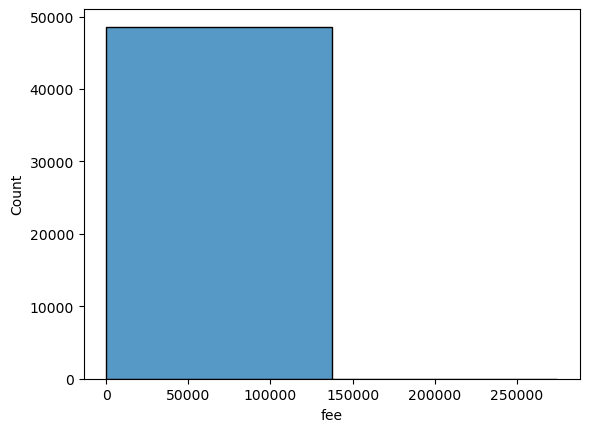

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['fee'],bins=2)
plt.show()

In [22]:
from scipy.stats import zscore

df['z_fee'] = zscore(df['fee'])

In [23]:
df.to_csv('../data/processed_data.csv', index=False)